# Improved CNN (Dog vs Cat)
Balanced training + better model + prediction

In [11]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
import matplotlib.pyplot as plt
import random


In [12]:
# Load Data
X_train = np.loadtxt('input_test.csv', delimiter=',')
Y_train = np.loadtxt('labels.csv', delimiter=',')
X_test = np.loadtxt('input_test.csv', delimiter=',')
Y_test = np.loadtxt('labels_test.csv', delimiter=',')

# Fix mismatch
Y_train = Y_train[:len(X_train)]
Y_test = Y_test[:len(X_test)]


In [13]:
# Reshape & Normalize
X_train = X_train.reshape(len(X_train),100,100,3)/255.0
X_test = X_test.reshape(len(X_test),100,100,3)/255.0
Y_train = Y_train.reshape(-1,1)
Y_test = Y_test.reshape(-1,1)

print(X_train.shape, Y_train.shape)

(400, 100, 100, 3) (400, 1)


In [14]:
# Check label balance
print(np.unique(Y_train, return_counts=True))

(array([0.]), array([400]))


In [15]:
# Improved CNN Model
model = Sequential()
model.add(Conv2D(32,(3,3),activation='relu',input_shape=(100,100,3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())
model.add(Dense(128,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 98, 98, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 47, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 21, 21, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     1,638,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,731,905 (6.61 MB)

 Trainable params: 1,731,905 (6.61 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# Train Model (more epochs)
history = model.fit(X_train, Y_train, epochs=15, validation_data=(X_test, Y_test))

Epoch 1/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 229ms/step - accuracy: 0.9300 - loss: 0.0583 - val_accuracy: 0.5000 - val_loss: 50.1032
Epoch 2/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 172ms/step - accuracy: 1.0000 - loss: 5.9390e-24 - val_accuracy: 0.5000 - val_loss: 80.6511
Epoch 3/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 179ms/step - accuracy: 1.0000 - loss: 3.8259e-38 - val_accuracy: 0.5000 - val_loss: 91.7520
Epoch 4/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 178ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 0.5000 - val_loss: 95.2214
Epoch 5/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 176ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 0.5000 - val_loss: 96.2371
Epoch 6/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 183ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 0.5000 - val_loss: 96.5248
Epoch 7/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 184ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 0.5000 - val_loss: 96.6047
Epoch 8/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 176ms/step - accuracy: 1.0000 - 

In [17]:
# Evaluate
loss, acc = model.evaluate(X_test, Y_test)
print('Accuracy:', acc)

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.5000 - loss: 96.6345
Accuracy: 0.5


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step


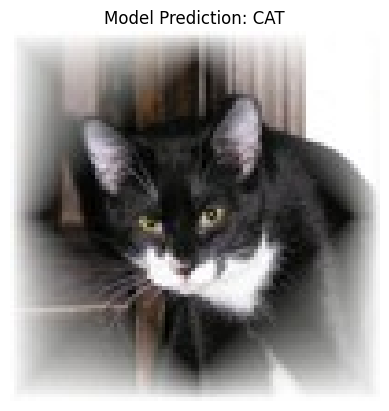

Raw Prediction: [[0.]]


In [18]:
# Prediction (Random Image)
class_names = ['CAT','DOG']

idx = random.randint(0,len(X_test)-1)
sample = X_test[idx]
pred = model.predict(sample.reshape(1,100,100,3))

label = 1 if pred > 0.5 else 0

plt.imshow(sample)
plt.title(f'Model Prediction: {class_names[label]}')
plt.axis('off')
plt.show()

print('Raw Prediction:', pred)